In [1]:
!pip install optuna lightgbm xgboost catboost koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 82.9 MB/s eta 0:00:00


In [2]:
#─────────────────────────────────────────────
# 0. 라이브러리
# ────────────────────────────────────────────-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, random, os, time

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

#한글 폰트 (Colab/로컬 공통)
try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams["font.family"] = "AppleGothic"   # macOS
    plt.rcParams["axes.unicode_minus"] = False

In [3]:
#─────────────────────────────────────────────
# 1. 시드 고정
# ─────────────────────────────────────────────
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

SEED = 42
seed_everything(SEED)

In [4]:
#─────────────────────────────────────────────
# 2. 데이터 로드
# ─────────────────────────────────────────────
# ❗ train/test 는 따로 로드 후 절대 섞지 않는다.
#  전처리 함수를 공통으로 만들고 각각에 적용 (fit은 train 기준)
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(train.dtypes)

Train: (7500, 11)  |  Test: (7500, 10)
ID                           object
Exercise_Duration           float64
Body_Temperature(F)         float64
BPM                         float64
Height(Feet)                float64
Height(Remainder_Inches)    float64
Weight(lb)                  float64
Weight_Status                object
Gender                       object
Age                           int64
Calories_Burned             float64
dtype: object


In [5]:
#데이터 확인
train.head()

,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0



  Train EDA
                           count        mean        std   min    25%    50%  \
Exercise_Duration         7500.0   15.501200   8.355300   1.0    8.0   15.0   
Body_Temperature(F)       7500.0  104.033573   1.412845  98.8  103.3  104.4   
BPM                       7500.0   95.498133   9.587331  69.0   88.0   95.0   
Height(Feet)              7500.0    5.248800   0.556663   4.0    5.0    5.0   
Height(Remainder_Inches)  7500.0    5.717600   3.497315   0.0    3.0    6.0   
Weight(lb)                7500.0  165.361187  33.308136  79.4  138.9  163.1   
Age                       7500.0   42.636000  16.883188  20.0   28.0   39.0   
Calories_Burned           7500.0   89.373467  62.817086   1.0   35.0   77.0   

                            75%    max  
Exercise_Duration          23.0   30.0  
Body_Temperature(F)       105.1  106.7  
BPM                       103.0  128.0  
Height(Feet)                6.0    7.0  
Height(Remainder_Inches)    9.0   12.0  
Weight(lb)                191

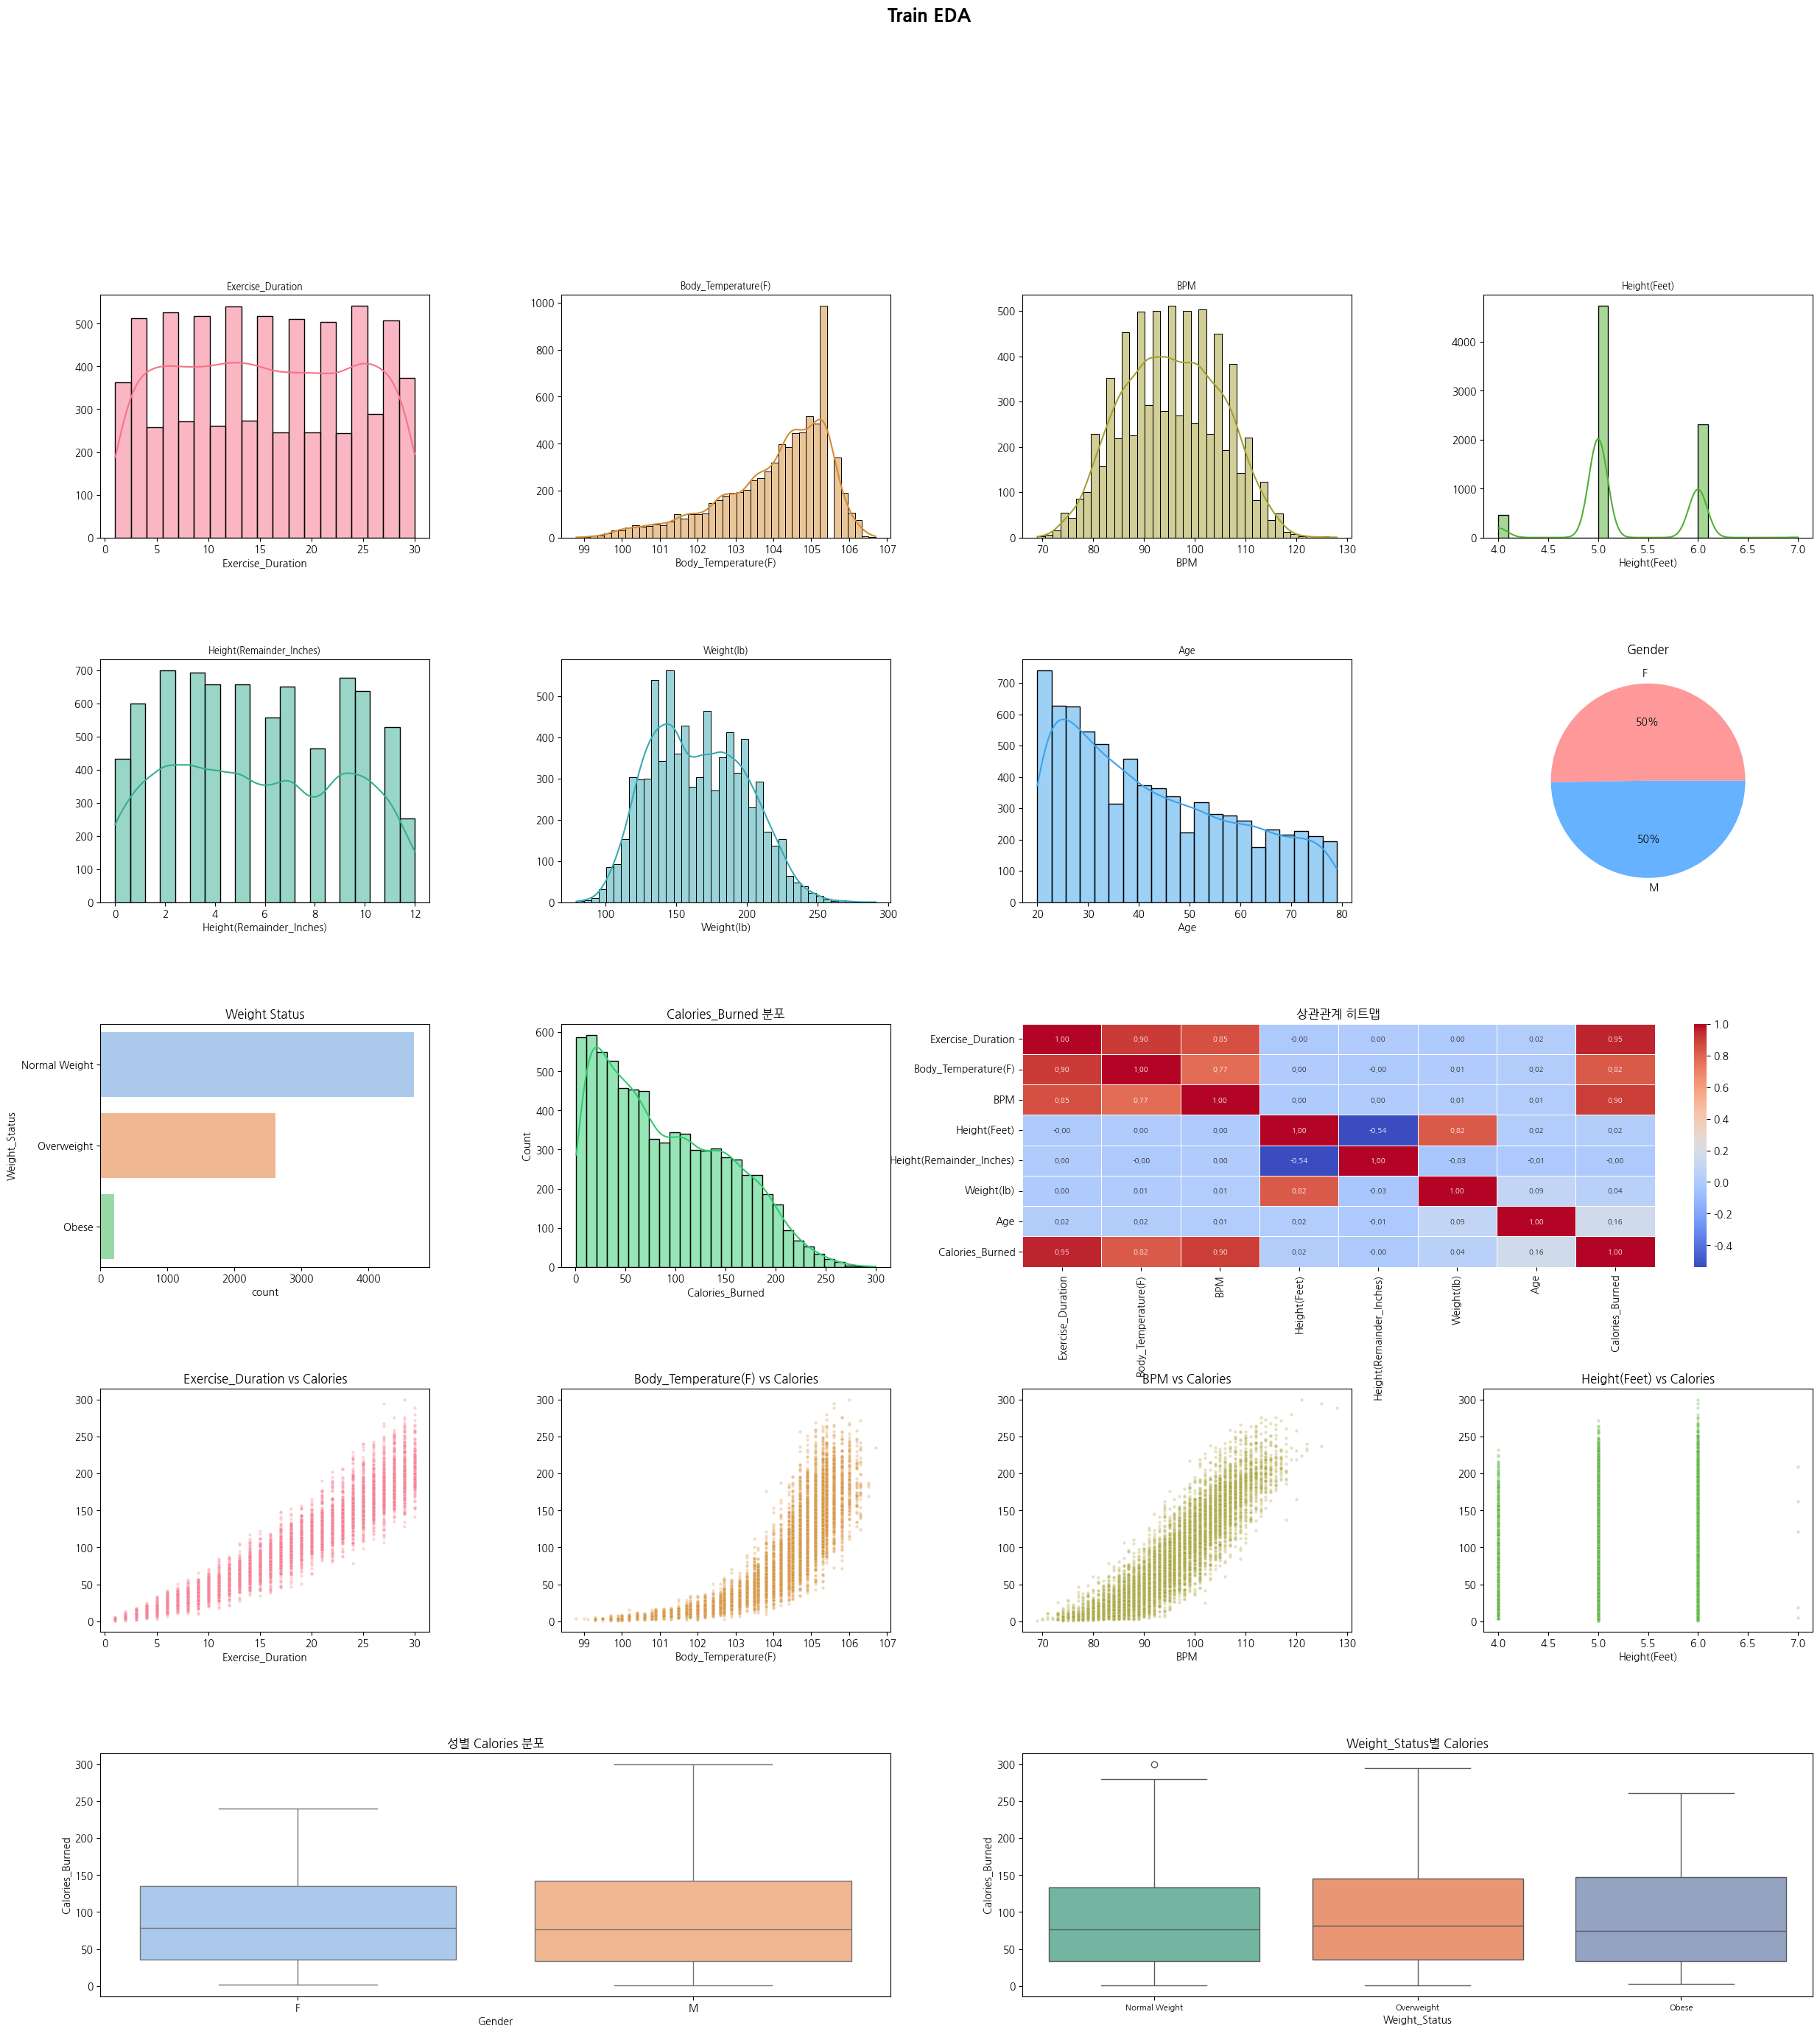

EDA 저장 → eda_plot.png


In [6]:
#─────────────────────────────────────────────
# 3. EDA
# ─────────────────────────────────────────────
def run_eda(df: pd.DataFrame, title: str = "Train EDA"):
    """기본 EDA + 시각화"""

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(df.describe().T)
    print("\n결측치:\n", df.isnull().sum())

    fig = plt.figure(figsize=(30, 30))
    fig.suptitle(title, fontsize=18, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(5, 4, figure=fig, hspace=0.5, wspace=0.4)

    num_cols = ["Exercise_Duration", "Body_Temperature(F)", "BPM",
                "Height(Feet)", "Height(Remainder_Inches)", "Weight(lb)", "Age"]

    # ── 수치형 분포 (KDE)
    for i, col in enumerate(num_cols):
        ax = fig.add_subplot(gs[i // 4, i % 4])
        sns.histplot(df[col], kde=True, ax=ax, color=sns.color_palette("husl", 9)[i])
        ax.set_title(col, fontsize=9)
        ax.set_ylabel("")

    # ── 성별 비율
    ax_g = fig.add_subplot(gs[1, 3])
    df["Gender"].value_counts().plot.pie(autopct="%1.0f%%", ax=ax_g,
                                         colors=["#FF9999","#66B2FF"])
    ax_g.set_title("Gender")
    ax_g.set_ylabel("")

    # ── Weight_Status 비율
    ax_w = fig.add_subplot(gs[2, 0])
    order = ["Normal Weight", "Overweight", "Obese"]
    sns.countplot(y="Weight_Status", data=df, order=order, ax=ax_w,
                  palette="pastel")
    ax_w.set_title("Weight Status")

    if "Calories_Burned" in df.columns:
        # ── 타겟 분포
        ax_t = fig.add_subplot(gs[2, 1])
        sns.histplot(df["Calories_Burned"], kde=True, ax=ax_t, color="#2ECC71")
        ax_t.set_title("Calories_Burned 분포")

        # ── 상관관계 히트맵
        ax_c = fig.add_subplot(gs[2, 2:4])
        corr_cols = num_cols + ["Calories_Burned"]
        corr = df[corr_cols].corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                    ax=ax_c, linewidths=0.5, annot_kws={"size": 7})
        ax_c.set_title("상관관계 히트맵")

        # ── 수치형 vs 타겟 scatter
        for i, col in enumerate(num_cols[:4]):
            ax = fig.add_subplot(gs[3, i])
            sns.scatterplot(x=col, y="Calories_Burned", data=df,
                            ax=ax, alpha=0.3, s=10,
                            color=sns.color_palette("husl", 9)[i])
            ax.set_title(f"{col} vs Calories")
            ax.set_ylabel("")

        # ── 성별 / Weight_Status별 Calories 박스플롯
        ax_gb = fig.add_subplot(gs[4, 0:2])
        sns.boxplot(x="Gender", y="Calories_Burned", data=df, ax=ax_gb,
                    palette="pastel")
        ax_gb.set_title("성별 Calories 분포")

        ax_wb = fig.add_subplot(gs[4, 2:4])
        sns.boxplot(x="Weight_Status", y="Calories_Burned", data=df,
                    order=order, ax=ax_wb, palette="Set2")
        ax_wb.set_title("Weight_Status별 Calories")
        ax_wb.tick_params(axis="x", labelsize=8)

    plt.savefig("eda_plot.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("EDA 저장 → eda_plot.png")


run_eda(train, "Train EDA")

In [7]:
#─────────────────────────────────────────────
# 4. 피처 엔지니어링
# ─────────────────────────────────────────────
# ❗ 데이터 누수 방지 원칙
#   - add_features()는 단순 수식 변환만 수행 (통계값 참조 없음)
#   - LabelEncoder는 train 기준으로 fit → test에 transform만 적용
#   - KFold 교차검증 내부에서만 scaler fit (현재 스케일링 미사용)

def get_activity_intensity(bpm_series: pd.Series, age_series: pd.Series) -> pd.Series:
    ages       = np.array([15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,95], dtype=float)
    low_cuts   = np.array([126,124,122,120,117,115,113,111,109,107,105,102,100,98,96,92], dtype=float)
    high_cuts  = np.array([150,147,145,142,139,137,134,132,129,127,124,122,119,117,114,109], dtype=float)

    age = pd.to_numeric(age_series, errors="coerce").astype(float).to_numpy()
    bpm = pd.to_numeric(bpm_series, errors="coerce").astype(float).to_numpy()

    low  = np.interp(age, ages, low_cuts)
    high = np.interp(age, ages, high_cuts)

    return pd.Series(
        np.where(bpm < low, 0, np.where(bpm < high, 1, 2)),   # 0=Light 1=Moderate 2=High
        index=bpm_series.index
    )


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """순수 수식 변환 — train/test 공통 적용 가능 (누수 없음)"""
    d = df.copy()

    # 단위 변환
    d["height_in"] = d["Height(Feet)"] * 12 + d["Height(Remainder_Inches)"]
    d["height_cm"] = d["height_in"] * 2.54
    d["height_m"]  = d["height_cm"] / 100.0
    d["weight_kg"] = d["Weight(lb)"] * 0.45359237
    d["temp_c"]    = (d["Body_Temperature(F)"] - 32) * (5 / 9)

    # BMI
    d["bmi"] = d["weight_kg"] / d["height_m"] ** 2

    # 기초대사량 (Harris-Benedict)
    is_male = d["Gender"].astype(str).str.upper().isin(["M", "MALE"])
    d["bmr"] = np.where(
        is_male,
        66.47  + 13.75 * d["weight_kg"] + 5.0  * d["height_cm"] - 6.76 * d["Age"],
        655.1  + 9.56  * d["weight_kg"] + 1.85 * d["height_cm"] - 4.68 * d["Age"],
    )

    # 최대 심박수
    d["mhr"] = 220 - d["Age"]

    # 심박 예비력
    HR_REST = 60
    d["hrr"]       = d["mhr"] - HR_REST
    d["hrr_ratio"] = (d["BPM"] - HR_REST) / d["hrr"]

    # 심박 스트레스
    d["hb_stress"]  = d["BPM"] / d["mhr"]

    # 대사 스트레스
    d["metabolic_stress"] = d["BPM"] * d["Exercise_Duration"]

    # 체중 보정 운동 부하
    d["relative_workload"] = (d["BPM"] * d["weight_kg"] * d["Exercise_Duration"]) / d["Age"]

    # 열 부하
    d["thermal_load"] = (d["temp_c"] - 37) * d["Exercise_Duration"]

    # 활동 강도 (수치형)
    d["activity_intensity"] = get_activity_intensity(d["BPM"], d["Age"])


    # 와라라라 코드
    # Intensity index
    d['Intensity_Index'] = d['BPM'] / d['Exercise_Duration']

     # Core interactions
    d['HR_Temp_Interaction'] = d['BPM'] * d['temp_c']
    d['HR_Duration_Interaction'] = d['BPM'] * d['Exercise_Duration']
    d['Metabolic_Load'] = d['BPM'] * d['temp_c'] * d['Exercise_Duration']
    d['Age_Duration'] = d['Age'] * d['Exercise_Duration']
    d['Age_Body_Temp'] = d['Age'] * d['temp_c']
    d['Duration_Body_Temp'] = d['Exercise_Duration'] * d['temp_c']
    d['Age_Duration_Temp'] = d['Age'] * d['Exercise_Duration'] * d['temp_c']

    # Height & Weight interactions
    d['Height_Weight'] = d['height_cm'] * d['weight_kg']
    d['Height_Duration'] = d['height_cm'] * d['Exercise_Duration']
    d['Weight_Duration'] = d['weight_kg'] * d['Exercise_Duration']
    d['Weight_HeartRate'] = d['weight_kg'] * d['BPM']
    d['Weight_BodyTemp'] = d['weight_kg'] * d['temp_c']
    d['Height_Temp_Interaction'] = d['height_cm'] * d['temp_c']
    d['Weight_Duration_Temp'] = d['weight_kg'] * d['Exercise_Duration'] * d['temp_c']
    d['Height_Duration_Temp'] = d['height_cm'] * d['Exercise_Duration'] * d['temp_c']
    d['Weight_HR_Duration'] = d['weight_kg'] * d['BPM'] * d['Exercise_Duration']
    d['Height_HR_Duration'] = d['height_cm'] * d['BPM'] * d['Exercise_Duration']

    # Advanced exertion interactions
    d['Weight_Intensity_Index'] = d['weight_kg'] * d['Intensity_Index']
    d['Height_Intensity_Index'] = d['height_cm'] * d['Intensity_Index']
    d['Weight_HR_Temp_Interaction'] = d['weight_kg'] * d['HR_Temp_Interaction']
    d['Height_HR_Temp_Interaction'] = d['height_cm'] * d['HR_Temp_Interaction']

    # Ratio and Normalized Features
    d['HR_per_kg'] = d['BPM'] / d['weight_kg']
    d['Duration_per_kg'] = d['Exercise_Duration'] / d['weight_kg']
    d['Temp_per_kg'] = d['temp_c'] / d['weight_kg']
    d['HR_per_cm'] = d['BPM'] / d['height_cm']
    d['Duration_per_cm'] = d['Exercise_Duration'] / d['height_cm']


    # Energy & exertion approximations
    d['Energy_Exerted'] = d['weight_kg'] * d['BPM'] * d['Exercise_Duration'] / 10000
    d['Weighted_Intensity'] = d['Intensity_Index'] * d['weight_kg']

    # BMR interactions
    d['BMR_HR'] = d['bmr'] * d['BPM']
    d['BMR_Duration'] = d['bmr'] * d['Exercise_Duration']
    d['BMR_Temp'] = d['bmr'] * d['temp_c']
    d['BMR_Intensity'] = d['bmr'] * d['Intensity_Index']

    # Polynomial and log features
    d['HR_Squared'] = d['BPM'] ** 2
    d['Duration_Squared'] = d['Exercise_Duration'] ** 2
    d['Temp_Squared'] = d['temp_c'] ** 2
    d['Log_HR'] = np.log1p(d['BPM'])

    # Sex-based interaction features (using string comparison for Gender before LabelEncoding)
    d['Sex_male_HR'] = d['BPM'] * (d['Gender'].astype(str).str.upper() == 'M')
    d['Sex_female_HR'] = d['BPM'] * (d['Gender'].astype(str).str.upper() == 'F')

    d['Sex_male_Weight'] = d['weight_kg'] * (d['Gender'].astype(str).str.upper() == 'M')
    d['Sex_female_Weight'] = d['weight_kg'] * (d['Gender'].astype(str).str.upper() == 'F')

    return d

In [8]:
#─────────────────────────────────────────────
# 5. 범주형 인코딩
# ────────────────────────────────────────────
# ❗ 범주형을 바꿀 때 train 기준으로 fit → test에 transform
#   train/test 따로 fit 하면 라벨 불일치 버그 발생

CAT_COLS = ["Gender", "Weight_Status"]

# 피처 엔지니어링 먼저
train_fe = add_features(train)
test_fe  = add_features(test)

# LabelEncoder — train fit → test transform
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    train_fe[col] = le.fit_transform(train_fe[col].astype(str))   # ← fit
    test_fe[col]  = le.transform(test_fe[col].astype(str))         # ← transform only
    label_encoders[col] = le
    print(f"[LabelEncoder] {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")


# 학습에 사용할 피처 선택
DROP_COLS = ["ID", "Calories_Burned",
             "Height(Feet)", "Height(Remainder_Inches)",   # 단위 변환된 컬럼이므로 대체
             "Weight(lb)", "Body_Temperature(F)", 'height_in', 'height_m']

FEATURE_COLS = [c for c in train_fe.columns if c not in DROP_COLS] # DROP_CPLS에 있는 것들 빼고 넣음

X      = train_fe[FEATURE_COLS] # 피처엔지니어링 한 df에서 feature columns 가져오기
y_orig = train_fe["Calories_Burned"] # 원래 스케일 타겟 (시각화·평가용)
y      = y_orig.copy()               # 로그 변환 없이 원래 스케일 그대로 학습
X_test = test_fe[FEATURE_COLS] # 피처엔지니어링 한 df에서 feature columns 적용하기기

print(f"\n학습 피처 수: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


[LabelEncoder] Gender: {'F': np.int64(0), 'M': np.int64(1)}
[LabelEncoder] Weight_Status: {'Normal Weight': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2)}

학습 피처 수: 59
['Exercise_Duration', 'BPM', 'Weight_Status', 'Gender', 'Age', 'height_cm', 'weight_kg', 'temp_c', 'bmi', 'bmr', 'mhr', 'hrr', 'hrr_ratio', 'hb_stress', 'metabolic_stress', 'relative_workload', 'thermal_load', 'activity_intensity', 'Intensity_Index', 'HR_Temp_Interaction', 'HR_Duration_Interaction', 'Metabolic_Load', 'Age_Duration', 'Age_Body_Temp', 'Duration_Body_Temp', 'Age_Duration_Temp', 'Height_Weight', 'Height_Duration', 'Weight_Duration', 'Weight_HeartRate', 'Weight_BodyTemp', 'Height_Temp_Interaction', 'Weight_Duration_Temp', 'Height_Duration_Temp', 'Weight_HR_Duration', 'Height_HR_Duration', 'Weight_Intensity_Index', 'Height_Intensity_Index', 'Weight_HR_Temp_Interaction', 'Height_HR_Temp_Interaction', 'HR_per_kg', 'Duration_per_kg', 'Temp_per_kg', 'HR_per_cm', 'Duration_per_cm', 'Energy_Exerted', 

In [9]:
#─────────────────────────────────────────────
# 6. Optuna 하이퍼파라미터 튜닝
# ─────────────────────────────────────────────
# ❗ 누수 방지: Optuna objective 내부에서 KFold로 교차검증
# → test 데이터 사용 금지

N_FOLDS   = 5
N_TRIALS  = 50   # 시간 여유 있으면 100~200 권장
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED) # 폴드 나누는 것 5개로 설정


# ── 고값 구간 오버샘플링 함수 ──────────────────────────────
def oversample_high(X_tr, y_tr, percentile=75, noise_std=0.01, repeat=2, seed=SEED):
    """
    고값 구간 데이터를 복제+노이즈로 augmentation.
    - percentile : 이 백분위수 이상인 샘플을 고값으로 간주 (기본 75)
    - noise_std  : 피처에 추가할 가우시안 노이즈의 표준편차 비율 (기본 0.01 = 1%)
    - repeat     : 고값 샘플을 몇 번 복제할지 (기본 2)
    """
    rng = np.random.RandomState(seed)
    threshold = np.percentile(y_tr, percentile)      # 고값 기준선
    high_mask = y_tr >= threshold

    X_high = X_tr[high_mask]
    y_high = y_tr[high_mask]
    n_high = high_mask.sum()

    print(f"    오버샘플링: 기준값={threshold:.1f} (상위 {100-percentile}%), "
          f"고값 샘플 {n_high}개 × {repeat}회 복제 → +{n_high * repeat}개")

    X_aug_list, y_aug_list = [X_tr], [y_tr]
    for _ in range(repeat):
        # 피처에 작은 가우시안 노이즈 추가 (완전 동일 복제 방지 → 과적합 억제)
        noise = rng.normal(0, noise_std, size=X_high.shape)
        X_noisy = X_high + noise * np.abs(X_high.values if hasattr(X_high, 'values') else X_high)
        X_aug_list.append(X_noisy)
        y_aug_list.append(y_high)

    X_out = pd.concat(X_aug_list, axis=0).reset_index(drop=True)
    y_out = pd.concat(y_aug_list, axis=0).reset_index(drop=True)
    return X_out, y_out


def rmse_cv(model, X, y, cv) -> float:
    scores = cross_val_score(model, X, y,
                             cv=cv, scoring="neg_root_mean_squared_error",
                             n_jobs=-1)
    return -scores.mean()

In [10]:
#── 6-1. XGBoost
def objective_xgb(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 1500, 1900),
        "max_depth":         trial.suggest_int("max_depth", 3, 7),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample":         trial.suggest_float("subsample", 0.2, 0.7),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 12),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma":             trial.suggest_float("gamma", 0, 1.0),
        "tree_method": "hist", "random_state": SEED, "n_jobs": -1,
    }
    model = XGBRegressor(**params) # model에 위에서 설정한 params 적용용
    return rmse_cv(model, X, y, kf)

In [11]:
#── 6-2. LightGBM
def objective_lgb(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 1000, 2000),
        "max_depth":          trial.suggest_int("max_depth", 2, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.03, 0.3, log=True),
        "num_leaves":         trial.suggest_int("num_leaves", 150, 300),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples":  trial.suggest_int("min_child_samples", 5, 30),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 1, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 1, log=True),
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }
    model = LGBMRegressor(**params)
    return rmse_cv(model, X, y, kf)

In [12]:
#── 6-3. CatBoost
def objective_cat(trial: optuna.Trial) -> float:
    params = {
        "iterations":        trial.suggest_int("iterations", 300, 2000),
        "depth":             trial.suggest_int("depth", 4, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength":   trial.suggest_float("random_strength", 0, 10),
        "border_count":      trial.suggest_int("border_count", 32, 255),
        'random_strength': trial.suggest_float("random_strength", 0, 10),


        "random_seed": SEED, "verbose": 0,
    }
    model = CatBoostRegressor(**params)
    return rmse_cv(model, X, y, kf)

In [13]:
from sklearn.model_selection import GridSearchCV

print("\n🔍 GridSearchCV 튜닝 시작...")
t0 = time.time()

# ============================================================
# ⚠️  아래 고정 파라미터 값을 Optuna에서 찾은 최적값으로 채우기.
#     그리드 서치할 파라미터만 param_grid에 여러 값을 넣고,
#     나머지는 모델 생성 시 고정.
# ============================================================

# ── XGBoost ──────────────────────────────────────────────────
xgb_fixed = {                          # Optuna 최적값으로 고정
    "subsample":        0.52,          # ← Optuna 값으로 수정
    "colsample_bytree": 0.71,          # ← Optuna 값으로 수정
    "min_child_weight": 0.71,             # ← Optuna 값으로 수정
    "reg_alpha":        1.1534,          # ← Optuna 값으로 수정
    "reg_lambda":       0.7779,           # ← Optuna 값으로 수정
    "gamma":            0.4991,           # ← Optuna 값으로 수정
    "tree_method": "hist", "random_state": SEED, "n_jobs": -1,
}
xgb_grid = {                           # 핵심 파라미터만 그리드 서치
    "n_estimators":  [1500, 1600, 1700, 1800, 1900],
    "max_depth":     [4, 5, 6],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
}

grid_xgb = GridSearchCV(
    XGBRegressor(**xgb_fixed),
    param_grid=xgb_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf, n_jobs=-1, verbose=1
)
grid_xgb.fit(X, y)

# ── LightGBM ────────────────────────────────────────────────
lgb_fixed = {
    "subsample":         0.9803,          # ← Optuna 값으로 수정
    "colsample_bytree":  0.8168,          # ← Optuna 값으로 수정
    "min_child_samples": 15,           # ← Optuna 값으로 수정
    "reg_alpha":         0.00787,        # ← Optuna 값으로 수정
    "reg_lambda":        0.03745,         # ← Optuna 값으로 수정
    "random_state": SEED, "n_jobs": -1, "verbose": -1,
}
lgb_grid = {
    "n_estimators":  [1300, 1400, 1500, 1600],
    "max_depth":     [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.07],
    "num_leaves":    [200, 210, 220],
}

grid_lgb = GridSearchCV(
    LGBMRegressor(**lgb_fixed),
    param_grid=lgb_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf, n_jobs=-1, verbose=1
)
grid_lgb.fit(X, y)

# ── CatBoost ─────────────────────────────────────────────────
cat_fixed = {
    "l2_leaf_reg":         0.0148,        # ← Optuna 값으로 수정
    "bagging_temperature": 0.4325,        # ← Optuna 값으로 수정
    "random_strength":     1.2526,        # ← Optuna 값으로 수정
    "border_count":        137,        # ← Optuna 값으로 수정
    "random_seed": SEED, "verbose": 0,
}
cat_grid = {
    "iterations":    [1700, 1800, 1900],
    "depth":         [5, 6, 7, 8],
    "learning_rate": [0.03, 0.04, 0.05],
}

grid_cat = GridSearchCV(
    CatBoostRegressor(**cat_fixed),
    param_grid=cat_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf, n_jobs=-1, verbose=1
)
grid_cat.fit(X, y)

print(f"\n튜닝 완료 ({time.time()-t0:.0f}s)")

print(f"  XGB  최적 RMSE: {-grid_xgb.best_score_:.4f}, 최적 하이퍼 파라미터: {grid_xgb.best_params_}")
print(f"  LGB  최적 RMSE: {-grid_lgb.best_score_:.4f}, 최적 하이퍼 파라미터: {grid_lgb.best_params_}")
print(f"  CAT  최적 RMSE: {-grid_cat.best_score_:.4f}, 최적 하이퍼 파라미터: {grid_cat.best_params_}")





🔍 GridSearchCV 튜닝 시작...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits

튜닝 완료 (13088s)
  XGB  최적 RMSE: 1.3071, 최적 하이퍼 파라미터: {'learning_rate': 0.02, 'max_depth': 5, 'n_estimators': 1900}
  LGB  최적 RMSE: 1.5185, 최적 하이퍼 파라미터: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 1600, 'num_leaves': 200}
  CAT  최적 RMSE: 1.0775, 최적 하이퍼 파라미터: {'depth': 7, 'iterations': 1900, 'learning_rate': 0.03}


In [14]:
#─────────────────────────────────────────────
# 7. 최적 파라미터로 최종 모델 학습
# ─────────────────────────────────────────────
# ── Out-Of-Fold 예측 생성 (앙상블·스태킹 기반)
# ❗ OOF방식으로 학습 → 검증 fold가 학습에 절대 참여하지 않음

def train_oof(model_class, params: dict,
              X: pd.DataFrame, y: pd.Series,
              X_test: pd.DataFrame, cv: KFold,
              model_name: str,
              use_oversample: bool = True):
    """
    OOF(Out-Of-Fold) 예측을 반환.
    - oof_preds  : 검증 세트 예측값 (길이 = len(X))
    - test_preds : 테스트 세트 예측값 (각 fold 평균)
    - importances: 피처 중요도 DataFrame
    - use_oversample: True면 고값 구간 오버샘플링 적용
    """
    oof_preds  = np.zeros(len(X))
    test_folds = np.zeros((len(X_test), cv.n_splits))
    imp_list   = []
    rmse_list  = []
    mae_list   = []
    r2_list    = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)): #  X의 행 인덱스를 5 fold로 나눈 뒤, 각 fold에 대해 (학습 인덱스, 검증 인덱스) 튜플을 반환하는 이터레이터
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # 고값 구간 오버샘플링 (학습 데이터에만 적용, 검증 데이터는 원본 유지)
        if use_oversample:
            X_tr, y_tr = oversample_high(X_tr, y_tr,
                                         percentile=75, noise_std=0.01, repeat=2)

        model = model_class(**params)

        # CatBoost early stopping 처리
        if model_class == CatBoostRegressor:
            model.fit(X_tr, y_tr,
                      eval_set=(X_val, y_val),
                      early_stopping_rounds=50,
                      verbose=0)
        else:
            model.fit(X_tr, y_tr)

        val_pred  = model.predict(X_val)

        # 로그 변환 없으므로 역변환 불필요 → 그대로 저장·평가
        oof_preds[val_idx] = val_pred
        test_folds[:, fold] = model.predict(X_test)

        fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        fold_mae  = mean_absolute_error(y_val, val_pred)
        fold_r2   = r2_score(y_val, val_pred)
        rmse_list.append(fold_rmse)
        mae_list.append(fold_mae)
        r2_list.append(fold_r2)
        print(f"  [{model_name}] Fold {fold+1} | RMSE: {fold_rmse:.4f}  MAE: {fold_mae:.4f}  R²: {fold_r2:.4f}")

        # 피처 중요도
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_
        elif hasattr(model, "get_feature_importance"):
            imp = model.get_feature_importance()
        else:
            imp = np.zeros(X_tr.shape[1])
        imp_list.append(imp)

    mean_rmse = np.mean(rmse_list)
    mean_mae  = np.mean(mae_list)
    mean_r2   = np.mean(r2_list)
    print(f"  [{model_name}] CV RMSE: {mean_rmse:.4f} ± {np.std(rmse_list):.4f}")
    print(f"  [{model_name}] CV MAE:  {mean_mae:.4f} ± {np.std(mae_list):.4f}")
    print(f"  [{model_name}] CV R²:   {mean_r2:.4f} ± {np.std(r2_list):.4f}\n")

    importances = pd.DataFrame(
        np.mean(imp_list, axis=0),
        index=X.columns, columns=["importance"]
    ).sort_values("importance", ascending=False)

    return oof_preds, test_folds.mean(axis=1), importances, mean_rmse, mean_mae, mean_r2


# XGBoost 파라미터 정리 (GridSearchCV 결과 + 고정 파라미터 병합)
xgb_params = {**xgb_fixed, **grid_xgb.best_params_}

lgb_params = {**lgb_fixed, **grid_lgb.best_params_}

cat_params = {**cat_fixed, **grid_cat.best_params_}

# CatBoost: iterations → n_estimators 키 이름 주의
if "n_estimators" in cat_params:
    cat_params["iterations"] = cat_params.pop("n_estimators")

print("=" * 60)
print("최종 OOF 학습 시작")
print("=" * 60)

oof_xgb, pred_xgb, imp_xgb, rmse_xgb, mae_xgb, r2_xgb = train_oof(
    XGBRegressor, xgb_params, X, y, X_test, kf, "XGBoost",
    use_oversample=True)

oof_lgb, pred_lgb, imp_lgb, rmse_lgb, mae_lgb, r2_lgb = train_oof(
    LGBMRegressor, lgb_params, X, y, X_test, kf, "LightGBM",
    use_oversample=True)

oof_cat, pred_cat, imp_cat, rmse_cat, mae_cat, r2_cat = train_oof(
    CatBoostRegressor, cat_params, X, y, X_test, kf, "CatBoost",
    use_oversample=True)

최종 OOF 학습 시작
    오버샘플링: 기준값=140.0 (상위 25%), 고값 샘플 1501개 × 2회 복제 → +3002개
  [XGBoost] Fold 1 | RMSE: 1.3561  MAE: 0.9385  R²: 0.9995
    오버샘플링: 기준값=138.0 (상위 25%), 고값 샘플 1516개 × 2회 복제 → +3032개
  [XGBoost] Fold 2 | RMSE: 1.3511  MAE: 0.9550  R²: 0.9995
    오버샘플링: 기준값=138.0 (상위 25%), 고값 샘플 1507개 × 2회 복제 → +3014개
  [XGBoost] Fold 3 | RMSE: 1.4339  MAE: 0.9575  R²: 0.9995
    오버샘플링: 기준값=138.0 (상위 25%), 고값 샘플 1504개 × 2회 복제 → +3008개
  [XGBoost] Fold 4 | RMSE: 1.3472  MAE: 0.9055  R²: 0.9995
    오버샘플링: 기준값=138.0 (상위 25%), 고값 샘플 1518개 × 2회 복제 → +3036개
  [XGBoost] Fold 5 | RMSE: 1.3035  MAE: 0.9167  R²: 0.9996
  [XGBoost] CV RMSE: 1.3584 ± 0.0422
  [XGBoost] CV MAE:  0.9346 ± 0.0206
  [XGBoost] CV R²:   0.9995 ± 0.0000

    오버샘플링: 기준값=140.0 (상위 25%), 고값 샘플 1501개 × 2회 복제 → +3002개
  [LightGBM] Fold 1 | RMSE: 1.5757  MAE: 1.0942  R²: 0.9994
    오버샘플링: 기준값=138.0 (상위 25%), 고값 샘플 1516개 × 2회 복제 → +3032개
  [LightGBM] Fold 2 | RMSE: 1.4514  MAE: 1.0481  R²: 0.9995
    오버샘플링: 기준값=138.0 (상위 25%), 고값 샘플 150

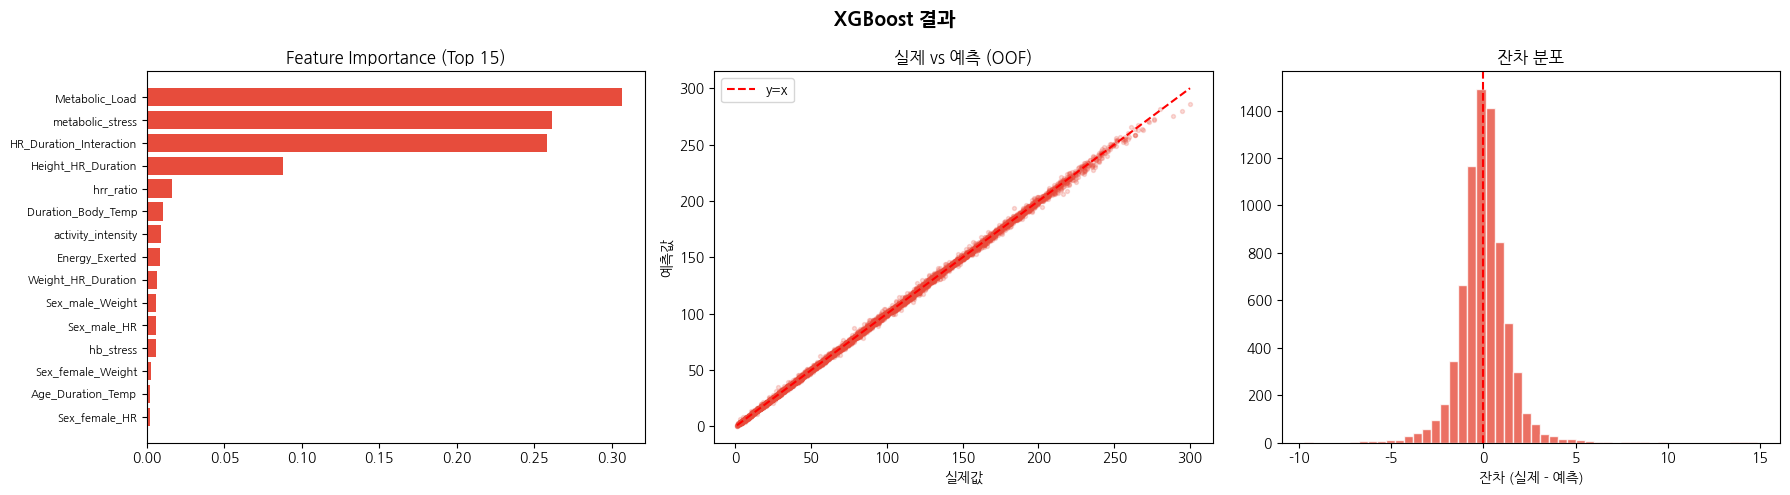

저장 → result_xgboost.png


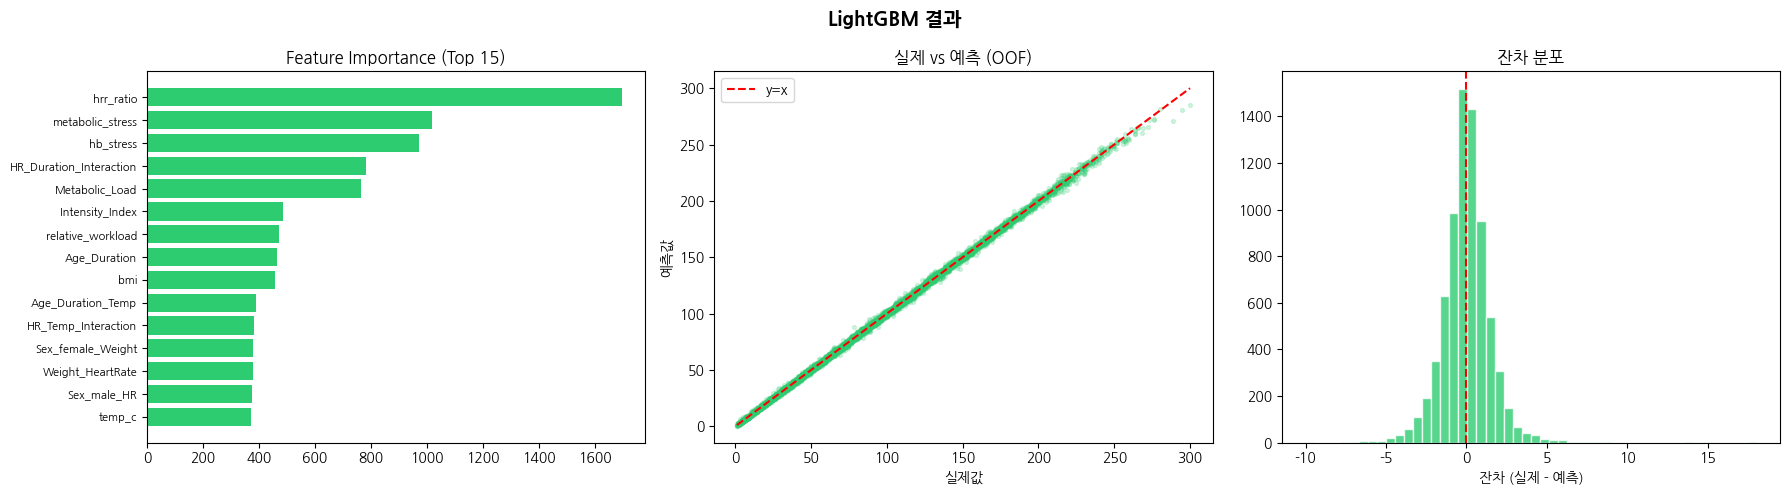

저장 → result_lightgbm.png


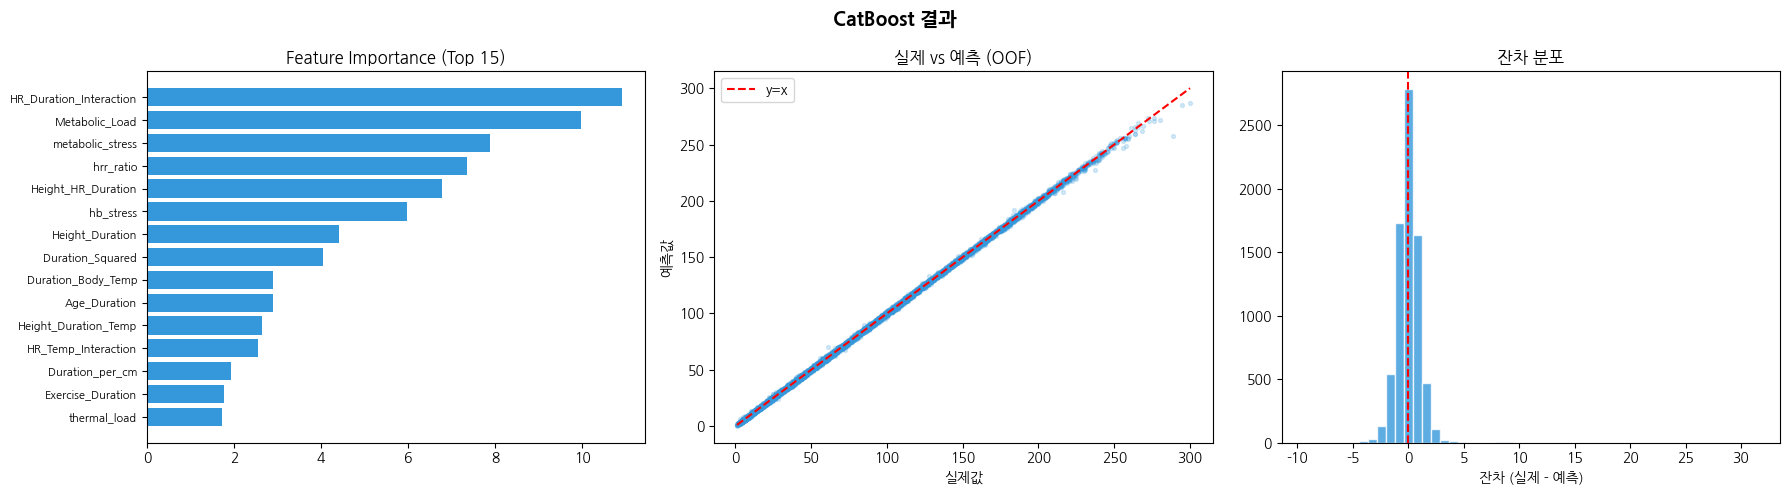

저장 → result_catboost.png


In [15]:
 #─────────────────────────────────────────────
# 8. 시각화  (Q7)
# ─────────────────────────────────────────────

def plot_model_results(oof_preds, imp_df, y_true, model_name, color):
    """모델별 결과 시각화 (feature importance, 예측 vs 실제, 잔차)"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{model_name} 결과", fontsize=14, fontweight="bold")

    # ── Feature Importance (상위 15개)
    top15 = imp_df.head(15)
    axes[0].barh(top15.index[::-1], top15["importance"][::-1], color=color)
    axes[0].set_title("Feature Importance (Top 15)")
    axes[0].tick_params(axis="y", labelsize=8)

    # ── 예측 vs 실제
    axes[1].scatter(y_true, oof_preds, alpha=0.2, s=8, color=color)
    lims = [y_true.min(), y_true.max()]
    axes[1].plot(lims, lims, "r--", lw=1.5, label="y=x")
    axes[1].set_xlabel("실제값")
    axes[1].set_ylabel("예측값")
    axes[1].set_title("실제 vs 예측 (OOF)")
    axes[1].legend()

    # ── 잔차 분포
    residuals = y_true - oof_preds
    axes[2].hist(residuals, bins=50, color=color, edgecolor="white", alpha=0.8)
    axes[2].axvline(0, color="red", lw=1.5, linestyle="--")
    axes[2].set_title("잔차 분포")
    axes[2].set_xlabel("잔차 (실제 - 예측)")

    plt.tight_layout()
    fname = f"result_{model_name.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {fname}")


plot_model_results(oof_xgb, imp_xgb, y_orig, "XGBoost",  "#E74C3C")
plot_model_results(oof_lgb, imp_lgb, y_orig, "LightGBM", "#2ECC71")
plot_model_results(oof_cat, imp_cat, y_orig, "CatBoost", "#3498DB")

In [16]:
#─────────────────────────────────────────────
# 9. 앙상블 · 가중평균  (RMSE 최소화)
# ─────────────────────────────────────────────
# ❗ 전략:
#   ① 최적 가중치 탐색 (Grid Search)
#   ② 가중 평균 → 단일 모델보다 낮은 RMSE 목표

def find_best_weights(oof_list, y_true, step=0.05):
    """
    3개 모델에 대해 w1+w2+w3=1 제약 하에 RMSE 최소 가중치 탐색
    """
    best_rmse = np.inf
    best_w    = (1/3, 1/3, 1/3)
    weights   = np.arange(0, 1 + step, step)

    for w1 in weights:
        for w2 in weights:
            w3 = 1.0 - w1 - w2
            if w3 < 0 or w3 > 1:
                continue
            blend = w1 * oof_list[0] + w2 * oof_list[1] + w3 * oof_list[2]
            rmse  = np.sqrt(mean_squared_error(y_true, blend))
            if rmse < best_rmse:
                best_rmse = rmse
                best_w    = (round(w1, 2), round(w2, 2), round(w3, 2))

    blend = best_w[0] * oof_list[0] + best_w[1] * oof_list[1] + best_w[2] * oof_list[2]
    mae_blend = mean_absolute_error(y_true, blend)
    r2_blend  = r2_score(y_true, blend)
    return best_w, best_rmse, mae_blend, r2_blend


print("앙상블 최적 가중치 탐색 중...")
best_w, best_rmse_blend, best_mae_blend, best_r2_blend = find_best_weights([oof_xgb, oof_lgb, oof_cat], y_orig)
w_xgb, w_lgb, w_cat = best_w

print(f"\n최적 가중치: XGB={w_xgb}  LGB={w_lgb}  CAT={w_cat}")
print(f"\n모델별 OOF 지표 (RMSE / MAE / R²):")
print(f"  XGBoost  : RMSE {rmse_xgb:.4f}  MAE {mae_xgb:.4f}  R² {r2_xgb:.4f}")
print(f"  LightGBM : RMSE {rmse_lgb:.4f}  MAE {mae_lgb:.4f}  R² {r2_lgb:.4f}")
print(f"  CatBoost : RMSE {rmse_cat:.4f}  MAE {mae_cat:.4f}  R² {r2_cat:.4f}")
print(f"  Blend    : RMSE {best_rmse_blend:.4f}  MAE {best_mae_blend:.4f}  R² {best_r2_blend:.4f}  ← 앙상블 최종")

앙상블 최적 가중치 탐색 중...

최적 가중치: XGB=0.25  LGB=0.15  CAT=0.6

모델별 OOF 지표 (RMSE / MAE / R²):
  XGBoost  : RMSE 1.3584  MAE 0.9346  R² 0.9995
  LightGBM : RMSE 1.4986  MAE 1.0593  R² 0.9994
  CatBoost : RMSE 1.0821  MAE 0.7501  R² 0.9997
  Blend    : RMSE 0.9580  MAE 0.6403  R² 0.9998  ← 앙상블 최종


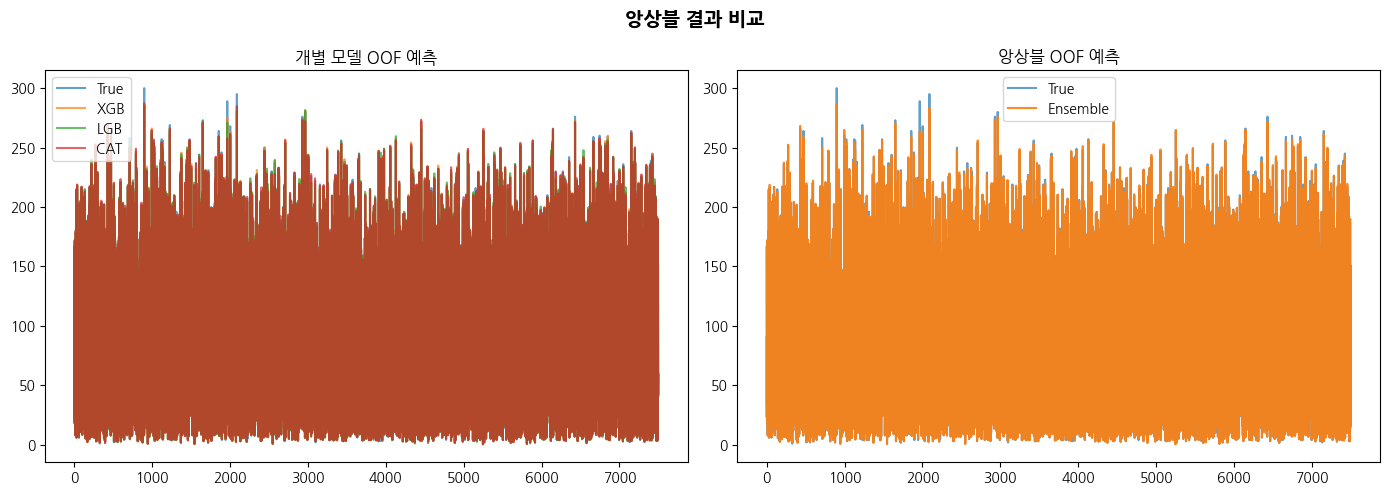

In [17]:
# ─────────────────────────────────────────────
# 10. 앙상블 결과 시각화
# ─────────────────────────────────────────────

# 앙상블 OOF 생성
oof_blend = (
    w_xgb * oof_xgb +
    w_lgb * oof_lgb +
    w_cat * oof_cat
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("앙상블 결과 비교", fontsize=14, fontweight="bold")

# ① 모델별 OOF 비교
axes[0].plot(y_orig.values, label="True", alpha=0.7)
axes[0].plot(oof_xgb, label="XGB", alpha=0.7)
axes[0].plot(oof_lgb, label="LGB", alpha=0.7)
axes[0].plot(oof_cat, label="CAT", alpha=0.7)
axes[0].set_title("개별 모델 OOF 예측")
axes[0].legend()

# ② 앙상블 vs 실제값
axes[1].plot(y_orig.values, label="True", alpha=0.7)
axes[1].plot(oof_blend, label="Ensemble", alpha=0.9)
axes[1].set_title("앙상블 OOF 예측")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# 모델별 RMSE 막대그래프
names  = ["XGBoost", "LightGBM", "CatBoost", "Blend"]
rmses  = [rmse_xgb, rmse_lgb, rmse_cat, best_rmse_blend]
colors = ["#E74C3C", "#2ECC71", "#3498DB", "#F39C12"]
bars   = axes[0].bar(names, rmses, color=colors, edgecolor="white")
axes[0].set_title("모델별 OOF RMSE 비교")
axes[0].set_ylabel("RMSE")
for bar, v in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f"{v:.2f}",
                 ha="center", va="bottom", fontsize=9)

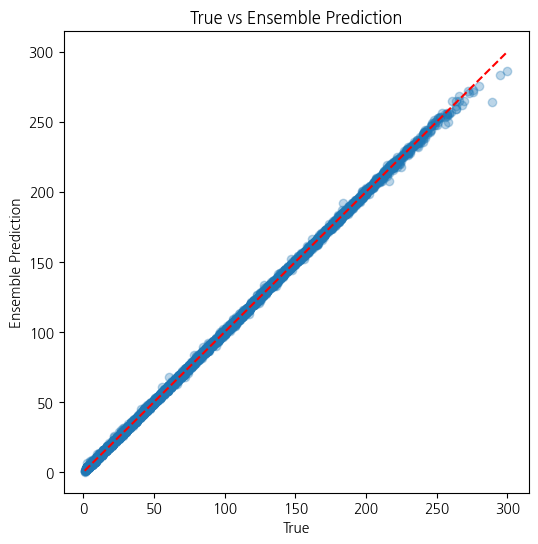

In [19]:
# True vs Prediction 산점도

plt.figure(figsize=(6,6))
plt.scatter(y_orig, oof_blend, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True")
plt.ylabel("Ensemble Prediction")
plt.title("True vs Ensemble Prediction")
plt.show()

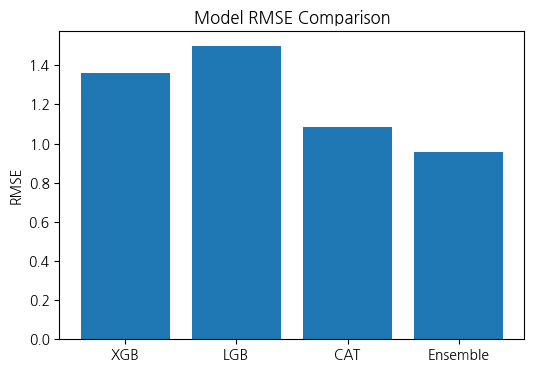

In [20]:
# RMSE 막대그래프

rmse_values = [rmse_xgb, rmse_lgb, rmse_cat, best_rmse_blend]
labels = ["XGB", "LGB", "CAT", "Ensemble"]

plt.figure(figsize=(6,4))
plt.bar(labels, rmse_values)
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

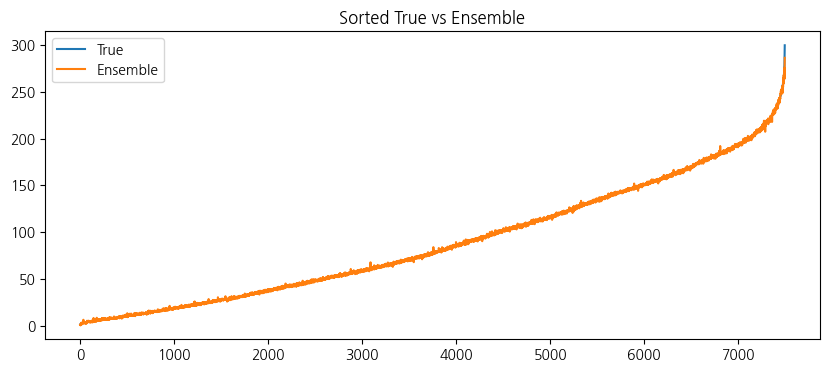

In [21]:
# 정렬 후 라인그래프

sorted_idx = np.argsort(y_orig.values)

plt.figure(figsize=(10,4))
plt.plot(y_orig.values[sorted_idx], label="True")
plt.plot(oof_blend[sorted_idx], label="Ensemble")
plt.legend()
plt.title("Sorted True vs Ensemble")
plt.show()

In [22]:
# 최종 앙상블 예측 vs 실제
oof_blend = w_xgb * oof_xgb + w_lgb * oof_lgb + w_cat * oof_cat
axes[1].scatter(y_orig, oof_blend, alpha=0.2, s=8, color="#F39C12")
lims = [y.min(), y.max()]
axes[1].plot(lims, lims, "r--", lw=1.5, label="y=x")
axes[1].set_xlabel("실제값")
axes[1].set_ylabel("예측값")
axes[1].set_title("앙상블 실제 vs 예측 (OOF)")
axes[1].legend()

plt.tight_layout()
plt.savefig("result_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 → result_ensemble.png")

<Figure size 640x480 with 0 Axes>

저장 → result_ensemble.png


In [23]:
# ─────────────────────────────────────────────
# 10. 최종 예측 및 제출 파일 생성
# ─────────────────────────────────────────────
test_blend = w_xgb * pred_xgb + w_lgb * pred_lgb + w_cat * pred_cat

# 음수 예측값 클리핑 (칼로리는 0 이상)
test_blend = np.clip(test_blend, 0, None)

submission = pd.DataFrame({
    "ID": test["ID"],
    "Calories_Burned": test_blend
})
submission.to_csv("submit.csv", index=False)
print(f"\n제출 파일 생성 완료: submit.csv  ({len(submission)}행)")
print(submission.head())


제출 파일 생성 완료: submit.csv  (7500행)
          ID  Calories_Burned
0  TEST_0000       172.768178
1  TEST_0001       189.129314
2  TEST_0002        53.046595
3  TEST_0003       161.229540
4  TEST_0004       224.751489


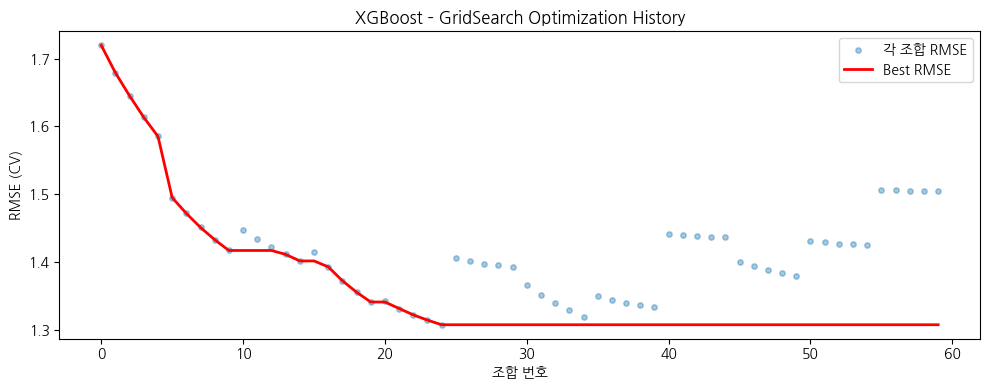

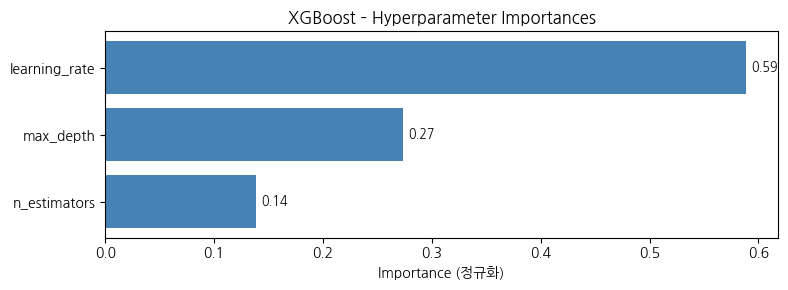

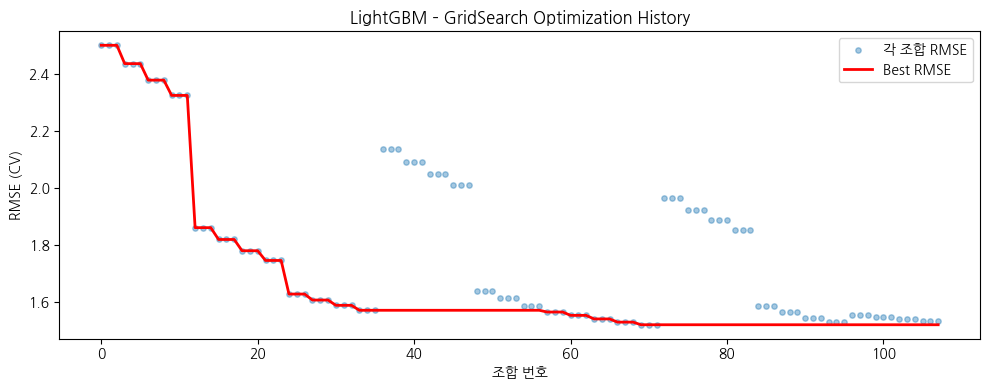

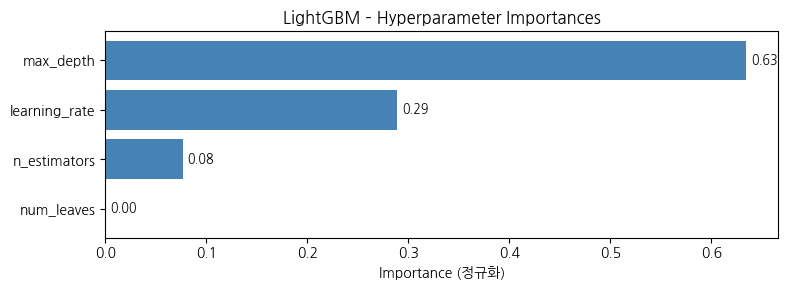

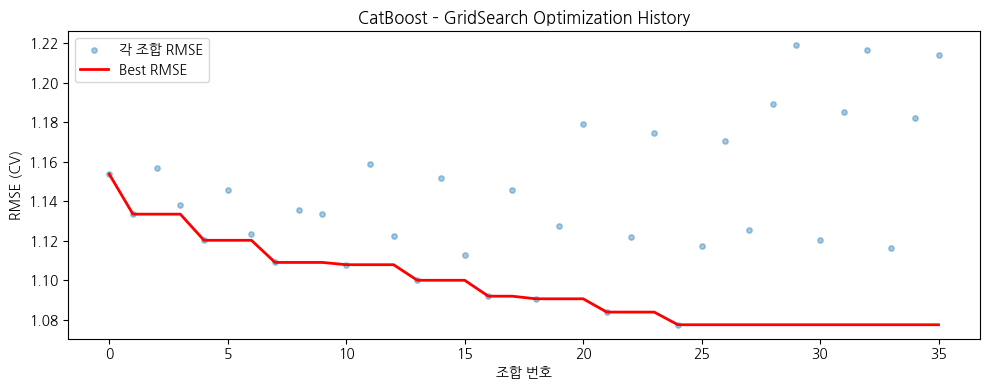

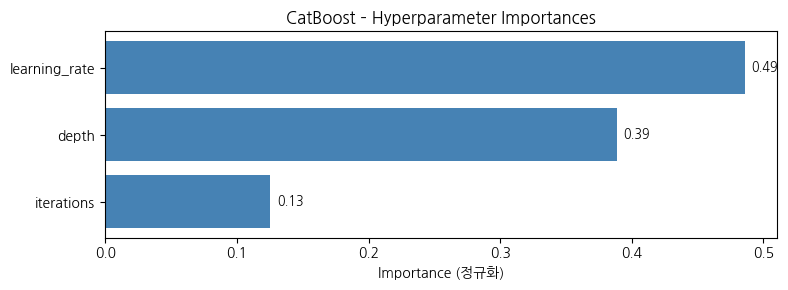

In [24]:
#─────────────────────────────────────────────
# 부록: GridSearchCV 결과 시각화
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

def plot_grid_optimization_history(grid_cv, title="Optimization History"):
    """GridSearchCV 결과를 Optuna optimization_history 스타일로 시각화"""
    results = pd.DataFrame(grid_cv.cv_results_)
    rmse = -results["mean_test_score"]          # neg_rmse → rmse
    best_so_far = rmse.cummin()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(range(len(rmse)), rmse, alpha=0.4, s=15, label="각 조합 RMSE")
    ax.plot(range(len(best_so_far)), best_so_far, color="red", linewidth=2, label="Best RMSE")
    ax.set_xlabel("조합 번호")
    ax.set_ylabel("RMSE (CV)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_grid_param_importances(grid_cv, title="Hyperparameter Importances"):
    """GridSearchCV 결과를 Optuna param_importances 스타일로 시각화
       각 파라미터 값별 평균 RMSE 분산(표준편차)을 중요도로 사용"""
    results = pd.DataFrame(grid_cv.cv_results_)
    results["rmse"] = -results["mean_test_score"]

    param_cols = [c for c in results.columns if c.startswith("param_")]
    importances = {}
    for col in param_cols:
        name = col.replace("param_", "")
        group_means = results.groupby(col)["rmse"].mean()
        importances[name] = group_means.std()   # 값 변화에 따른 RMSE 변동폭

    imp_series = pd.Series(importances).sort_values()
    imp_norm = imp_series / imp_series.sum()     # 비율로 정규화

    fig, ax = plt.subplots(figsize=(8, max(3, len(imp_norm) * 0.5)))
    bars = ax.barh(imp_norm.index, imp_norm.values, color="steelblue")
    for bar, val in zip(bars, imp_norm.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=9)
    ax.set_xlabel("Importance (정규화)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# ── XGBoost ──
plot_grid_optimization_history(grid_xgb, "XGBoost – GridSearch Optimization History")
plot_grid_param_importances(grid_xgb,    "XGBoost – Hyperparameter Importances")

# ── LightGBM ──
plot_grid_optimization_history(grid_lgb, "LightGBM – GridSearch Optimization History")
plot_grid_param_importances(grid_lgb,    "LightGBM – Hyperparameter Importances")

# ── CatBoost ──
plot_grid_optimization_history(grid_cat, "CatBoost – GridSearch Optimization History")
plot_grid_param_importances(grid_cat,    "CatBoost – Hyperparameter Importances")